In [ ]:
# Import & Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\data\master\Master Data - fitur & label.xlsx"
df = pd.read_excel(path)

print(df.shape)
display(df.head())


(27, 19)


,kode_kab_kota,kab_kota,luas_km2,kepadatan_penduduk,apotek,puskesmas_total,klinik,rsu_total,penduduk_2024,rasio_apotek,dens_apotek,rasio_puskesmas_total,dens_puskesmas_total,rasio_klinik,dens_klinik,rasio_rsu_total,dens_rsu_total,skor_layanan,kelas_layanan
0,3201,KABUPATEN BOGOR,2991.78,1899,466,258,45,27,5681390.22,0.820222,0.155760,0.454114,0.086236,0.079206,0.015041,0.047524,0.009025,-0.771693,Rendah
1,3202,KABUPATEN SUKABUMI,4164.15,679,206,282,9,9,2827457.85,0.728570,0.049470,0.997362,0.067721,0.031831,0.002161,0.031831,0.002161,-0.616339,Rendah
2,3203,KABUPATEN CIANJUR,3631.92,712,219,157,10,7,2585927.04,0.846892,0.060299,0.607132,0.043228,0.038671,0.002753,0.027070,0.001927,-0.843022,Rendah
3,3204,KABUPATEN BANDUNG,1740.84,2156,418,100,14,17,3753251.04,1.113701,0.240114,0.266436,0.057444,0.037301,0.008042,0.045294,0.009765,-0.910243,Rendah
4,3205,KABUPATEN GARUT,3101.24,876,325,276,10,9,2716686.24,1.196310,0.104797,1.015944,0.088997,0.036810,0.003225,0.033129,0.002902,-0.413293,Rendah


In [ ]:
# Cek kolom penting (biar aman)
needed = [
    "kab_kota", "kelas_layanan", "skor_layanan",
    "kepadatan_penduduk",
    "rasio_apotek", "rasio_puskesmas_total", "rasio_klinik", "rasio_rsu_total",
    "dens_apotek", "dens_puskesmas_total", "dens_klinik", "dens_rsu_total"
]
missing = [c for c in needed if c not in df.columns]
print("Missing:", missing)


Missing: []


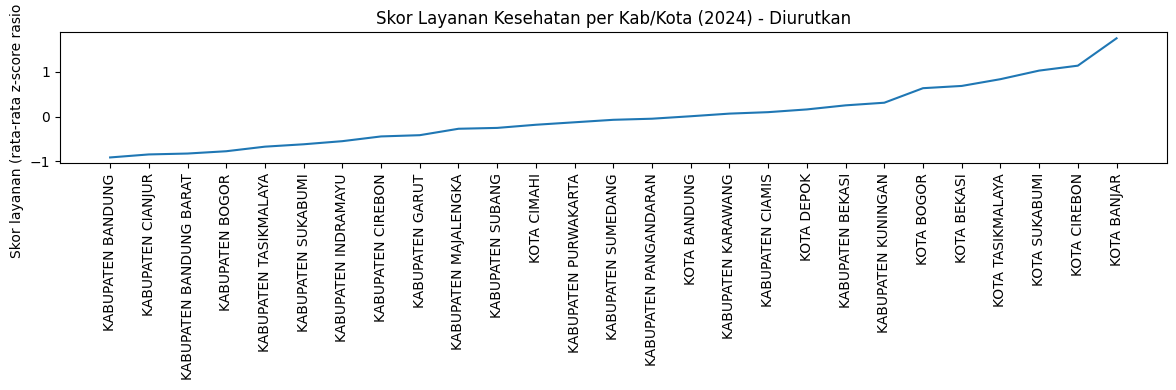

In [15]:
# Visualisasi “Tren” (line chart) versi data 2024 (fokus 2024, tren waktu nggak ada. Jadi kita bikin line chart skor layanan antar kab/kota (diurutkan skornya).)
tmp = df.sort_values("skor_layanan")[["kab_kota","skor_layanan"]].reset_index(drop=True)

plt.figure(figsize=(12,4))
plt.plot(tmp["kab_kota"], tmp["skor_layanan"])
plt.xticks(rotation=90)
plt.title("Skor Layanan Kesehatan per Kab/Kota (2024) - Diurutkan")
plt.ylabel("Skor layanan (rata-rata z-score rasio layanan)")
plt.tight_layout()
plt.savefig(r"C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\outputs\figures\01_line_skor_layanan_2024.png",
            dpi=200, bbox_inches="tight")
plt.show()

<Figure size 1000x400 with 0 Axes>

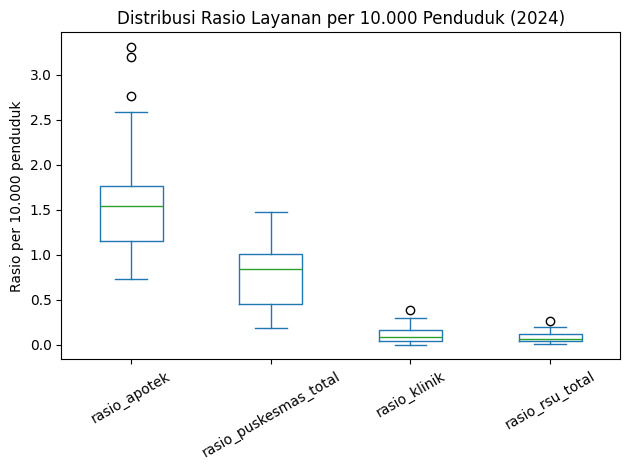

In [16]:
# Distribusi rasio antar wilayah (boxplot)
rasio_cols = ["rasio_apotek","rasio_puskesmas_total","rasio_klinik","rasio_rsu_total"]

plt.figure(figsize=(10,4))
df[rasio_cols].plot(kind="box", rot=30)
plt.title("Distribusi Rasio Layanan per 10.000 Penduduk (2024)")
plt.ylabel("Rasio per 10.000 penduduk")
plt.tight_layout()
plt.savefig(r"C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\outputs\figures\02_boxplot_rasio_layanan_2024.png",
            dpi=200, bbox_inches="tight")
plt.show()


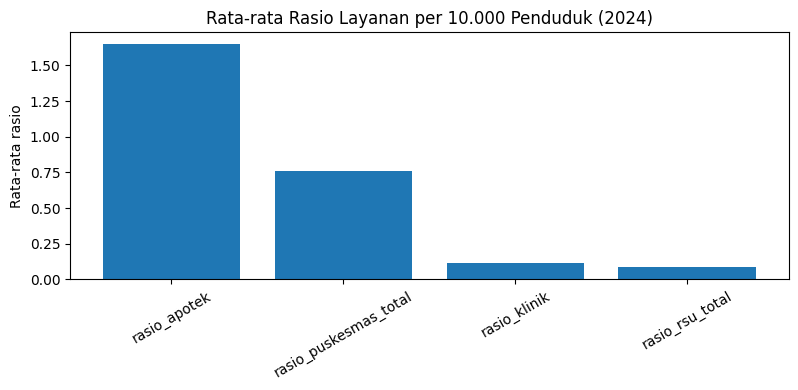

In [24]:
# Bar chart untuk melihat perbandingan rata-rata rasio
means = df[rasio_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(means.index, means.values)
plt.xticks(rotation=30)
plt.title("Rata-rata Rasio Layanan per 10.000 Penduduk (2024)")
plt.ylabel("Rata-rata rasio")
plt.tight_layout()
plt.savefig(r"C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\outputs\figures\03_ratarata_rasio_layanan_2024.png",
            dpi=200, bbox_inches="tight")
plt.show()


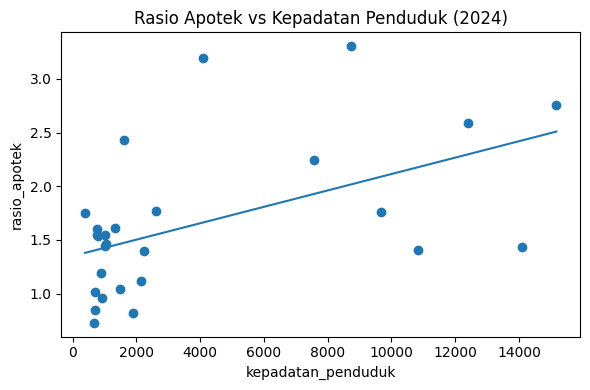

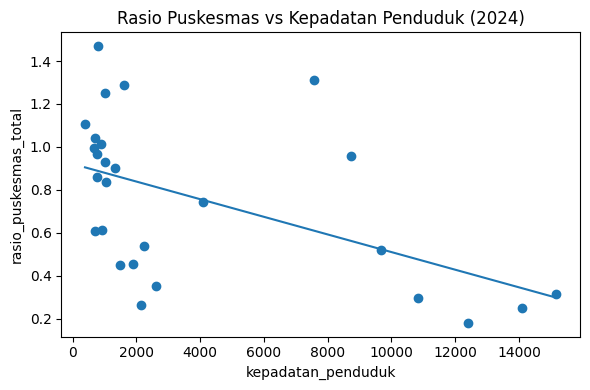

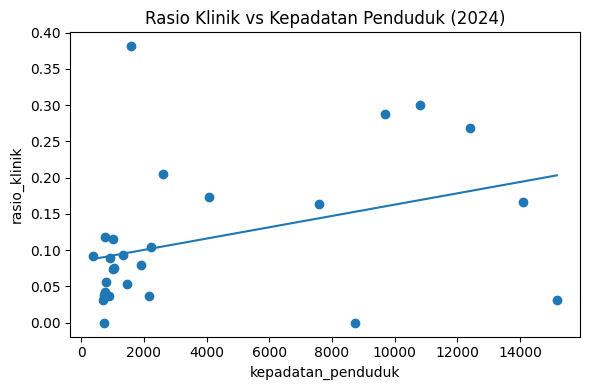

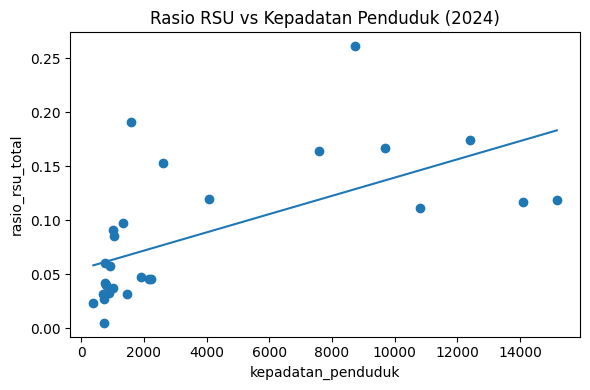

In [ ]:

def scatter_with_fit(x_col, y_col, title=None, save_path=None):
    x = df[x_col].values
    y = df[y_col].values
    
    plt.figure(figsize=(6,4))
    plt.scatter(x, y)
    
    # line fit sederhana
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b)
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title if title else f"{y_col} vs {x_col}")
    plt.tight_layout()

    # simpan gambar (PNG) kalau save_path diisi
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        
    plt.show()


base = r"C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\outputs\figures"
os.makedirs(base, exist_ok=True)

scatter_with_fit("kepadatan_penduduk", "rasio_apotek",
                 "Rasio Apotek vs Kepadatan Penduduk (2024)",
                 save_path=rf"{base}\04_scatter_rasio_apotek_vs_kepadatan.png")

scatter_with_fit("kepadatan_penduduk", "rasio_puskesmas_total",
                 "Rasio Puskesmas vs Kepadatan Penduduk (2024)",
                 save_path=rf"{base}\05_scatter_rasio_puskesmas_vs_kepadatan.png")


scatter_with_fit("kepadatan_penduduk", "rasio_klinik",
                 "Rasio Klinik vs Kepadatan Penduduk (2024)",
                 save_path=rf"{base}\06_scatter_rasio_klinik_vs_kepadatan.png")

scatter_with_fit("kepadatan_penduduk", "rasio_rsu_total",
                 "Rasio RSU vs Kepadatan Penduduk (2024)",
                 save_path=rf"{base}\07_scatter_rasio_rsu_total_vs_kepadatan.png")


In [9]:
# Identifikasi kab/kota rasio terendah & tertinggi
def top_bottom(metric, n=5):
    bottom = df.sort_values(metric)[["kab_kota", metric, "kelas_layanan"]].head(n).reset_index(drop=True)
    top = df.sort_values(metric, ascending=False)[["kab_kota", metric, "kelas_layanan"]].head(n).reset_index(drop=True)
    return bottom, top

metrics = ["rasio_apotek", "rasio_puskesmas_total", "rasio_klinik", "rasio_rsu_total"]

for m in metrics:
    bottom, top = top_bottom(m, n=5)
    print(f"\n===== {m} | 5 TERENDAH =====")
    display(bottom)
    print(f"===== {m} | 5 TERTINGGI =====")
    display(top)



===== rasio_apotek | 5 TERENDAH =====


,kab_kota,rasio_apotek,kelas_layanan
0,KABUPATEN SUKABUMI,0.728570,Rendah
1,KABUPATEN BOGOR,0.820222,Rendah
2,KABUPATEN CIANJUR,0.846892,Rendah
3,KABUPATEN INDRAMAYU,0.961274,Rendah
4,KABUPATEN TASIKMALAYA,1.015011,Rendah


===== rasio_apotek | 5 TERTINGGI =====


,kab_kota,rasio_apotek,kelas_layanan
0,KOTA CIREBON,3.305657,Tinggi
1,KOTA TASIKMALAYA,3.197190,Tinggi
2,KOTA BANDUNG,2.760890,Sedang
3,KOTA BEKASI,2.586951,Tinggi
4,KOTA BANJAR,2.431501,Tinggi



===== rasio_puskesmas_total | 5 TERENDAH =====


...

,kab_kota,rasio_klinik,kelas_layanan
0,KOTA BANJAR,0.381412,Tinggi
1,KOTA DEPOK,0.300422,Tinggi
2,KOTA BOGOR,0.287464,Tinggi
3,KOTA BEKASI,0.268529,Tinggi
4,KABUPATEN BEKASI,0.204648,Tinggi



===== rasio_rsu_total | 5 TERENDAH =====


,kab_kota,rasio_rsu_total,kelas_layanan
0,KABUPATEN TASIKMALAYA,0.005205,Rendah
1,KABUPATEN PANGANDARAN,0.023023,Sedang
2,KABUPATEN CIANJUR,0.027070,Rendah
3,KABUPATEN SUKABUMI,0.031831,Rendah
4,KABUPATEN BANDUNG BARAT,0.031846,Rendah


===== rasio_rsu_total | 5 TERTINGGI =====


,kab_kota,rasio_rsu_total,kelas_layanan
0,KOTA CIREBON,0.260973,Tinggi
1,KOTA BANJAR,0.190706,Tinggi
2,KOTA BEKASI,0.173976,Tinggi
3,KOTA BOGOR,0.166915,Tinggi
4,KOTA SUKABUMI,0.164044,Tinggi


In [10]:
# Simpan semua grafik & tabel ke folder outputs
import os

base_out = r"C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\outputs"
fig_dir = os.path.join(base_out, "figures")
tab_dir = os.path.join(base_out, "tables")
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tab_dir, exist_ok=True)

# simpan tabel ranking
with pd.ExcelWriter(os.path.join(tab_dir, "ranking_top_bottom_2024.xlsx")) as w:
    for m in metrics:
        bottom, top = top_bottom(m, n=5)
        bottom.to_excel(w, sheet_name=f"{m}_bottom", index=False)
        top.to_excel(w, sheet_name=f"{m}_top", index=False)

print("Saved ranking tables to:", os.path.join(tab_dir, "ranking_top_bottom_2024.xlsx"))


Saved ranking tables to: C:\SALMAAAAAA\Salma As Student\Machine Learning\ta-ml-jabar-2024\outputs\tables\ranking_top_bottom_2024.xlsx
